# Notebook 22 — Declining Oscillator Confirmation + cl7 Positive-Asymmetry Test

**Goals:**
1. Confirm the 8th shape class (declining oscillator) with independent datasets beyond Arctic sea ice
2. Test whether commodity prices land in the cl7 positive-asymmetry cluster

---

## Pre-run Predictions

| Dataset | Predicted class | Reasoning |
|---|---|---|
| Antarctic sea ice | cl0 — same declining oscillator class as Arctic | Same structure: strong annual cycle + long-term decline. Different hemisphere, independent data. If it joins cl0, the 8th class has two pure members. |
| NAO (North Atlantic Oscillation) | cl7 or ENSO-adjacent | Irregular climate oscillation, different basin from ENSO. Tests whether cl7 extends beyond Pacific to Atlantic climate modes. |
| PDO (Pacific Decadal Oscillation) | cl7 with ENSO | Same Pacific basin as ENSO ONI but different timescale (decadal vs inter-annual). May land close to ENSO or in its own region. |

**Key question:** Does Antarctic sea ice independently replicate the cl0 cluster from nb21, or does it land somewhere else? If it joins cl0, the "declining oscillator" class is confirmed with two pure-cluster members from the same structural family.

In [2]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from chronos import ChronosPipeline
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
ALL_COLS = TIMEDOM_COLS + SPECTRAL_COLS
TARGET_LEN = 64

print(f'PyTorch {torch.__version__}')
print(f'Target series length: {TARGET_LEN} points')

PyTorch 2.11.0+cu130
Target series length: 64 points


In [3]:
# ============================================================
# HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def spectral_features_fixed(series):
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)
    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0
    dom_freq = float(freqs[np.argmax(power)])
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    return {
        'dominant_freq':   dom_freq,
        'spectral_entropy': sp_ent,
        'power_low':  float(power_ac[:low_end].sum()  / total_ac),
        'power_mid':  float(power_ac[low_end:mid_end].sum() / total_ac),
        'power_high': float(power_ac[mid_end:].sum()  / total_ac),
    }


def extract_all_features(series):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta(arr),
    }
    return {**td, **spectral_features_fixed(arr)}


def resample_series(series, target_length=TARGET_LEN):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n = len(arr)
    if n == target_length:
        return arr
    x_old = np.linspace(0, 1, n)
    x_new = np.linspace(0, 1, target_length)
    return interp1d(x_old, arr, kind='linear')(x_new)

# ---- Pre-initialise all dataset variables ----
# Each dataset cell overwrites these. If a cell fails or is skipped,
# COMBINE still finds a valid (empty) variable and continues.
_empty_raw = np.zeros((0, TARGET_LEN))
for _v in ['df_covid_all','df_ss_all','df_lh_all','df_k_all','df_temp_all',
           'df_ecg_all','df_sf_all','df_sl_all','df_oni_all','df_vix_all',
           'df_ch4_all','df_ohc_all','df_ice_all',
           'df_ant_all','df_wti_all','df_cu_all']:
    globals()[_v] = pd.DataFrame()
for _v in ['raw_covid','raw_ss','raw_lh','raw_k','raw_temp',
           'raw_ecg','raw_sf','raw_sl','raw_oni','raw_vix',
           'raw_ch4','raw_ohc','raw_ice',
           'raw_ant','raw_wti','raw_cu']:
    globals()[_v] = _empty_raw.copy()
del _v, _empty_raw

print('Helpers OK — all dataset vars pre-initialised')

Helpers OK — all dataset vars pre-initialised


In [4]:
# ============================================================
# DATASET 1: COVID (first + second wave)
# ============================================================
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records, raw_series = [], []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
            raw_series.append(resample_series(w))
df_covid_all = pd.DataFrame(records)
raw_covid = np.stack(raw_series)
print(df_covid_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_covid.shape}')

{'covid_second_wave': 209, 'covid_first_wave': 202}   raw shape: (411, 64)


In [5]:
# ============================================================
# DATASET 2: Sunspot cycles
# ============================================================
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80: cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records, raw_series = [], []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
    raw_series.append(resample_series(c))
df_ss_all = pd.DataFrame(records)
raw_ss = np.stack(raw_series)
print(f'Sunspot: {len(df_ss_all)} cycles  raw shape: {raw_ss.shape}')

Sunspot: 24 cycles  raw shape: (24, 64)


In [6]:
# ============================================================
# DATASET 3: Lynx-hare
# ============================================================
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records, raw_series = [], []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_lh_all = pd.DataFrame(records)
raw_lh = np.stack(raw_series)
print(f'Lynx-hare: {len(df_lh_all)}  raw shape: {raw_lh.shape}')

Lynx-hare: 26  raw shape: (26, 64)


In [7]:
# ============================================================
# DATASET 4: Keeling CO2 (seasonal + trend)
# ============================================================
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = (seg, 'keeling_seasonal')
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = (trend_vals[i:i+120], 'keeling_trend')
records, raw_series = [], []
for name, (s, ds) in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': ds, 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_k_all = pd.DataFrame(records)
raw_k = np.stack(raw_series)
print(df_k_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_k.shape}')

{'keeling_seasonal': 68, 'keeling_trend': 58}   raw shape: (126, 64)


In [8]:
# ============================================================
# DATASET 5: Global temperature anomaly
# ============================================================
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records, raw_series = [], []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_temp_all = pd.DataFrame(records)
raw_temp = np.stack(raw_series)
print(f'Temperature: {len(df_temp_all)}  raw shape: {raw_temp.shape}')

Temperature: 31  raw shape: (31, 64)


In [9]:
# ============================================================
# DATASET 6: ECG (requires ECGFiveDays.zip in data/raw/)
# ============================================================
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

ts_files = list(dest_dir.rglob('*.ts'))
all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
records, raw_series = [], []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_ecg_all = pd.DataFrame(records)
raw_ecg = np.stack(raw_series)
print(f'ECG: {len(df_ecg_all)}  kurtosis={df_ecg_all["kurtosis"].mean():.2f}  raw shape: {raw_ecg.shape}')

Cached: ../data/raw/ECGFiveDays
ECG: 884  kurtosis=15.17  raw shape: (884, 64)


In [10]:
# ============================================================
# DATASET 7: Streamflow (USGS)
# ============================================================
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',   '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=20) as resp:   # 20s per station
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

# Pre-initialise outputs — safe if cell is interrupted
df_sf_all = pd.DataFrame()
raw_sf    = np.zeros((0, TARGET_LEN))

print(f'Fetching {len(STATIONS)} USGS stations (20s timeout each)...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')

records, raw_series = [], []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
    raw_series.append(resample_series(log_flow))

if records:
    df_sf_all = pd.DataFrame(records)
    raw_sf    = np.stack(raw_series)
print(f'Streamflow: {len(df_sf_all)} stations  raw shape: {raw_sf.shape}')

Fetching 25 USGS stations (20s timeout each)...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  OK alabama_al
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Streamflow: 25 stations  raw shape: (25, 64)


In [11]:
# ============================================================
# DATASET 8: Sea level (Phase 1b)
# ============================================================
dest = RAW_DIR / 'sea_level_nasa.csv'
if dest.exists(): dest.unlink()
urls = [
    'https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelRise/slr/slr_sla_gbl_keep_all_66.csv',
    'https://sealevel.colorado.edu/files/current/sl_ns_global.txt',
]
content = None
for url in urls:
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        if b'<!' not in r.content[:20]: content = r.content; print(f'OK: {url[:50]}'); break
    except Exception as e: print(f'  {url[:40]}: {e}')
if content is None: raise RuntimeError('Sea level: all URLs failed')
dest.write_bytes(content)
df_sl = pd.read_csv(dest, comment='#')
mission_cols = [c for c in df_sl.columns if c != 'year']
df_sl['gmsl'] = df_sl[mission_cols].mean(axis=1, skipna=True)
df_sl = df_sl[['year','gmsl']].dropna().rename(columns={'year':'year_frac'}).sort_values('year_frac').reset_index(drop=True)
values_sl = df_sl['gmsl'].values
year_fracs = df_sl['year_frac'].values
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_sl)-window, step):
    s = values_sl[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'sl_{int(year_fracs[i])}','dataset':'sea_level','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_sl_all = pd.DataFrame(records)
raw_sl = np.stack(raw_series)
print(f'Sea level: {len(df_sl_all)}  raw shape: {raw_sl.shape}')

OK: https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelR
Sea level: 120  raw shape: (120, 64)


In [12]:
# ============================================================
# DATASET 9: ENSO ONI (Phase 1b)
# ============================================================
dest = RAW_DIR / 'oni_enso.txt'
if not dest.exists():
    r = requests.get('https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',
                     headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    r.raise_for_status(); dest.write_bytes(r.content)
rows = []
with open(dest) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4 and not line.strip().startswith('SEAS'):
            try: rows.append({'year': int(parts[1]), 'oni': float(parts[3])})
            except (ValueError, IndexError): pass
df_oni = pd.DataFrame(rows).dropna()
values_oni = df_oni['oni'].values
window, step = 36, 6
records, raw_series = [], []
for i in range(0, len(values_oni)-window, step):
    s = values_oni[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'oni_{df_oni["year"].iloc[i]}','dataset':'enso_oni','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_oni_all = pd.DataFrame(records)
raw_oni = np.stack(raw_series)
print(f'ENSO ONI: {len(df_oni_all)}  raw shape: {raw_oni.shape}')

ENSO ONI: 147  raw shape: (147, 64)


In [13]:
# ============================================================
# DATASET 10: VIX (Phase 1b)
# ============================================================
dest = RAW_DIR / 'vix_fred.csv'
if dest.exists(): dest.unlink()
for name, url in [('cboe-cdn','https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv'),
                   ('cboe-www','https://www.cboe.com/publish/ScheduledTask/MktData/datahouse/vixcurrent.csv')]:
    try:
        r = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}, timeout=60)
        r.raise_for_status()
        if b'<!DOCTYPE' not in r.content[:200] and len(r.content) > 100:
            dest.write_bytes(r.content); print(f'VIX OK ({name})'); break
    except Exception as e: print(f'  {name}: {e}')
else: raise RuntimeError('All VIX sources failed')
df_vix = pd.read_csv(dest, parse_dates=['DATE'], dayfirst=False)
df_vix = df_vix[['DATE','CLOSE']].rename(columns={'DATE':'date','CLOSE':'vix'}).dropna()
df_vix = df_vix.set_index('date').resample('MS').mean().dropna().reset_index()
values_vix = df_vix['vix'].values
window, step = 24, 3
records, raw_series = [], []
for i in range(0, len(values_vix)-window, step):
    s = values_vix[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'vix_{df_vix["date"].iloc[i].year}_{i}','dataset':'vix','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_vix_all = pd.DataFrame(records)
raw_vix = np.stack(raw_series)
print(f'VIX: {len(df_vix_all)}  raw shape: {raw_vix.shape}')

VIX OK (cboe-cdn)
VIX: 138  raw shape: (138, 64)


In [14]:
# ============================================================
# DATASET 11: Atmospheric methane CH4 (NOAA GML global monthly)
# (Phase 2b, new — testing "clean monotonic" sub-type)
# Replaces glacier mass balance (OWID URL dead)
# ============================================================
dest = RAW_DIR / 'ch4_monthly.txt'
if dest.exists(): dest.unlink()
r = requests.get('https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.txt',
                 headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print('CH4 OK')

rows = []
for line in r.content.decode('utf-8').splitlines():
    line = line.strip()
    if not line or line.startswith('#'): continue
    parts = line.split()
    if len(parts) >= 7:
        try:
            year, month = int(parts[0]), int(parts[1])
            avg   = float(parts[3])   # monthly mean
            trend = float(parts[5])   # deseasonalised trend
            if avg > 0 and trend > 0:
                rows.append({'year': year, 'month': month, 'average': avg, 'trend': trend})
        except (ValueError, IndexError):
            pass

df_ch4 = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
print(f'CH4 data: {len(df_ch4)} monthly values  ({df_ch4["year"].min()}–{df_ch4["year"].max()})')
print(f'Trend range: {df_ch4["trend"].min():.1f}–{df_ch4["trend"].max():.1f} ppb')

# Use the trend column (deseasonalised) — isolates the clean monotonic signal
values_ch4 = df_ch4['trend'].values
years_ch4  = df_ch4['year'].values

# Rolling windows — 120 months (10 years), step 12
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ch4) - window, step):
    s = values_ch4[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ch4_{years_ch4[i]}', 'dataset': 'ch4_trend', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ch4_all = pd.DataFrame(records)
raw_ch4 = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'CH4 trend: {len(df_ch4_all)} windows  raw shape: {raw_ch4.shape}')

CH4 OK
CH4 data: 509 monthly values  (1983–2025)
Trend range: 1635.1–1939.2 ppb
CH4 trend: 33 windows  raw shape: (33, 64)


In [15]:
# ============================================================
# DATASET 12: Ocean heat content 0-700m (NOAA NCEI quarterly)
# (Phase 2b, new — testing "noisy directional" sub-type)
# ============================================================
dest = RAW_DIR / 'ocean_heat_content.csv'
if dest.exists(): dest.unlink()

url = 'https://www.ncei.noaa.gov/data/oceans/woa/DATA_ANALYSIS/3M_HEAT_CONTENT/DATA/basin/3month/ohc_levitus_climdash_seasonal.csv'
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print(f'OHC OK ({len(r.content)} bytes)')

# Format: no header, two columns — "YYYY-Q,value"  (Q = 3,6,9,12 for quarters)
rows = []
for line in r.content.decode('utf-8').splitlines():
    line = line.strip()
    if not line: continue
    try:
        date_part, val_part = line.split(',')
        year, quarter = date_part.split('-')
        rows.append({'year': int(year), 'quarter': int(quarter), 'ohc': float(val_part)})
    except (ValueError, IndexError):
        continue

df_ohc = pd.DataFrame(rows).sort_values(['year','quarter']).reset_index(drop=True)
print(f'OHC data: {len(df_ohc)} quarterly values  ({df_ohc["year"].min()}–{df_ohc["year"].max()})')
print(f'OHC range: {df_ohc["ohc"].min():.3f} to {df_ohc["ohc"].max():.3f}')

values_ohc = df_ohc['ohc'].values

# Rolling windows — 80 quarters (~20 years), step 8
window, step = 80, 8
records, raw_series = [], []
for i in range(0, len(values_ohc) - window, step):
    s = values_ohc[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ohc_{df_ohc["year"].iloc[i]}q{df_ohc["quarter"].iloc[i]}',
                  'dataset': 'ocean_heat', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ohc_all = pd.DataFrame(records)
raw_ohc = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Ocean heat: {len(df_ohc_all)} windows  raw shape: {raw_ohc.shape}')

OHC OK (4805 bytes)
OHC data: 284 quarterly values  (1955–2025)
OHC range: -8.007 to 23.254
Ocean heat: 26 windows  raw shape: (26, 64)


In [16]:
# ============================================================
# DATASET 13: Arctic sea ice extent (NSIDC monthly)
# (Phase 2b, new — testing "declining oscillator" hypothesis)
# Data: 12 separate monthly files, one per calendar month
# ============================================================
base_url = 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_{:02d}_extent_v4.0.csv'
all_rows = []
for month in range(1, 13):
    url = base_url.format(month)
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        for line in r.content.decode('utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('year'): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 5:
                try:
                    all_rows.append({'year': int(parts[0]), 'month': int(parts[1]), 'extent': float(parts[4])})
                except ValueError:
                    pass
        print(f'  month {month:02d}: OK')
    except Exception as e:
        print(f'  month {month:02d}: FAIL {e}')

df_ice = pd.DataFrame(all_rows)
df_ice = df_ice[df_ice['extent'] > 0].sort_values(['year','month']).reset_index(drop=True)
print(f'Sea ice data: {len(df_ice)} monthly values  ({df_ice["year"].min()}–{df_ice["year"].max()})')

values_ice = df_ice['extent'].values
# Rolling windows — 120 months (10 years), step 12
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ice) - window, step):
    s = values_ice[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ice_{df_ice["year"].iloc[i]}', 'dataset': 'arctic_sea_ice', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ice_all = pd.DataFrame(records)
raw_ice = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Arctic sea ice: {len(df_ice_all)} windows  raw shape: {raw_ice.shape}')

  month 01: OK
  month 02: OK
  month 03: OK
  month 04: OK
  month 05: OK
  month 06: OK
  month 07: OK
  month 08: OK
  month 09: OK
  month 10: OK
  month 11: OK
  month 12: OK
Sea ice data: 567 monthly values  (1978–2026)
Arctic sea ice: 38 windows  raw shape: (38, 64)


In [17]:
# ============================================================
# DATASET 14: Antarctic sea ice extent (NSIDC monthly)
# Same source as Arctic (nb21) — Southern hemisphere
# Testing: does it join cl0 (declining oscillator) with Arctic sea ice?
# ============================================================
base_url = 'https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/S_{:02d}_extent_v4.0.csv'
all_rows = []
for month in range(1, 13):
    url = base_url.format(month)
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        for line in r.content.decode('utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('year'): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 5:
                try:
                    all_rows.append({'year': int(parts[0]), 'month': int(parts[1]), 'extent': float(parts[4])})
                except ValueError:
                    pass
        print(f'  month {month:02d}: OK')
    except Exception as e:
        print(f'  month {month:02d}: FAIL {e}')

df_ant = pd.DataFrame(all_rows)
df_ant = df_ant[df_ant['extent'] > 0].sort_values(['year','month']).reset_index(drop=True)
print(f'Antarctic sea ice: {len(df_ant)} monthly values  ({df_ant["year"].min()}–{df_ant["year"].max()})')

values_ant = df_ant['extent'].values
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ant) - window, step):
    s = values_ant[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ant_{df_ant["year"].iloc[i]}', 'dataset': 'antarctic_sea_ice', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ant_all = pd.DataFrame(records)
raw_ant = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Antarctic sea ice: {len(df_ant_all)} windows  raw shape: {raw_ant.shape}')

  month 01: OK
  month 02: OK
  month 03: OK
  month 04: OK
  month 05: OK
  month 06: OK
  month 07: OK
  month 08: OK
  month 09: OK
  month 10: OK
  month 11: OK
  month 12: OK
Antarctic sea ice: 566 monthly values  (1978–2026)
Antarctic sea ice: 38 windows  raw shape: (38, 64)


In [18]:
# ============================================================
# DATASET 15: NAO — North Atlantic Oscillation monthly (NOAA CPC)
# Replacing WTI oil (FRED consistently times out)
# Testing: does another irregular climate oscillation land in cl7?
# ============================================================
dest = RAW_DIR / 'nao_monthly.txt'
if dest.exists(): dest.unlink()
url = 'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table'
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print(f'NAO OK ({len(r.content)} bytes)')

rows = []
for line in r.content.decode('utf-8').splitlines():
    parts = line.split()
    if not parts or not parts[0].isdigit(): continue
    year = int(parts[0])
    for month, val in enumerate(parts[1:13], start=1):
        try: rows.append({'year': year, 'month': month, 'nao': float(val)})
        except ValueError: pass

df_nao = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
print(f'NAO: {len(df_nao)} monthly values  ({df_nao["year"].min()}–{df_nao["year"].max()})')

values_nao = df_nao['nao'].values
window, step = 60, 6
records, raw_series = [], []
for i in range(0, len(values_nao) - window, step):
    s = values_nao[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'nao_{df_nao["year"].iloc[i]}m{df_nao["month"].iloc[i]}',
                  'dataset': 'nao', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_wti_all = pd.DataFrame(records)   # keep variable name for COMBINE compatibility
raw_wti = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
# rename dataset label
df_wti_all['dataset'] = 'nao'
print(f'NAO: {len(df_wti_all)} windows  raw shape: {raw_wti.shape}')
print(f'Mean skewness: {df_wti_all["skewness"].mean():.3f}')

NAO OK (6877 bytes)
NAO: 915 monthly values  (1950–2026)
NAO: 143 windows  raw shape: (143, 64)
Mean skewness: -0.112


In [19]:
# ============================================================
# DATASET 16: PDO — Pacific Decadal Oscillation monthly (NOAA PSL)
# Replacing copper (FRED consistently times out)
# Testing: does PDO also land in cl7 alongside ENSO?
# ============================================================
dest = RAW_DIR / 'pdo_monthly.txt'
if dest.exists(): dest.unlink()
url = 'https://psl.noaa.gov/data/correlation/pdo.data'
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print(f'PDO OK ({len(r.content)} bytes)')

rows = []
for line in r.content.decode('utf-8').splitlines():
    parts = line.split()
    if not parts or not parts[0].isdigit(): continue
    year = int(parts[0])
    for month, val in enumerate(parts[1:13], start=1):
        try:
            v = float(val)
            if v != -9.90: rows.append({'year': year, 'month': month, 'pdo': v})
        except ValueError: pass

df_pdo = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
print(f'PDO: {len(df_pdo)} monthly values  ({df_pdo["year"].min()}–{df_pdo["year"].max()})')

values_pdo = df_pdo['pdo'].values
window, step = 60, 6
records, raw_series = [], []
for i in range(0, len(values_pdo) - window, step):
    s = values_pdo[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'pdo_{df_pdo["year"].iloc[i]}m{df_pdo["month"].iloc[i]}',
                  'dataset': 'pdo', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_cu_all = pd.DataFrame(records)    # keep variable name for COMBINE compatibility
raw_cu = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
df_cu_all['dataset'] = 'pdo'
print(f'PDO: {len(df_cu_all)} windows  raw shape: {raw_cu.shape}')
print(f'Mean skewness: {df_cu_all["skewness"].mean():.3f}')

PDO OK (7514 bytes)
PDO: 933 monthly values  (1948–2025)
PDO: 146 windows  raw shape: (146, 64)
Mean skewness: 0.067


In [20]:
# ============================================================
# COMBINE — 16 datasets
# ============================================================
df_all = pd.concat([
    df_covid_all, df_ss_all, df_lh_all, df_k_all,
    df_temp_all, df_ecg_all, df_sf_all,
    df_sl_all, df_oni_all, df_vix_all,
    df_ch4_all, df_ohc_all, df_ice_all,    # nb21
    df_ant_all, df_wti_all, df_cu_all,     # nb22 new
], ignore_index=True)

X_raw_all = np.concatenate([
    raw_covid, raw_ss, raw_lh, raw_k,
    raw_temp, raw_ecg, raw_sf,
    raw_sl, raw_oni, raw_vix,
    raw_ch4, raw_ohc, raw_ice,
    raw_ant, raw_wti, raw_cu,
], axis=0)

valid_mask = df_all[ALL_COLS].notna().all(axis=1).values
df_all     = df_all[valid_mask].reset_index(drop=True)
X_raw_all  = X_raw_all[valid_mask]

DATASETS = sorted(df_all['dataset'].unique())
ORIG_9   = ['covid_first_wave','covid_second_wave','ecg','keeling_seasonal',
             'keeling_trend','lynx_hare','streamflow','sunspot_cycle','temperature']
PHASE1B  = ['enso_oni','sea_level','vix']
PHASE2B  = ['arctic_sea_ice','ch4_trend','ocean_heat']
PHASE22  = ['antarctic_sea_ice','nao','pdo']
ds_labels = df_all['dataset'].values

import seaborn as sns
palette  = sns.color_palette('tab20', len(DATASETS))
ds_color = {ds: palette[i] for i, ds in enumerate(DATASETS)}

print(f'Total instances:  {len(df_all)}')
print(f'Raw series shape: {X_raw_all.shape}')
assert len(df_all) == len(X_raw_all), 'ALIGNMENT ERROR'
print()
for ds in DATASETS:
    tag = '(22)' if ds in PHASE22 else '(2b)' if ds in PHASE2B else '(1b)' if ds in PHASE1B else '    '
    print(f'  {tag} {ds:25s}: {(df_all["dataset"]==ds).sum()}')

Total instances:  2356
Raw series shape: (2356, 64)

  (22) antarctic_sea_ice        : 38
  (2b) arctic_sea_ice           : 38
  (2b) ch4_trend                : 33
       covid_first_wave         : 202
       covid_second_wave        : 209
       ecg                      : 884
  (1b) enso_oni                 : 147
       keeling_seasonal         : 68
       keeling_trend            : 58
       lynx_hare                : 26
  (22) nao                      : 143
  (2b) ocean_heat               : 26
  (22) pdo                      : 146
  (1b) sea_level                : 120
       streamflow               : 25
       sunspot_cycle            : 24
       temperature              : 31
  (1b) vix                      : 138


New dataset             Nearest                    Dist    2nd nearest                Dist  
------------------------------------------------------------------------------------------
antarctic_sea_ice       arctic_sea_ice              0.179  streamflow                  0.931
nao                     temperature                 2.309  vix                         2.992
pdo                     streamflow                  0.346  vix                         0.694

Skewness profile (key feature for cl7 test):
dataset                   skewness   lag1_autocorr   zero_crossings
vix                          0.953           0.648            0.207
enso_oni                     0.316           0.956            0.074
temperature                  0.043           0.463            0.302
arctic_sea_ice              -0.377           0.850            0.169
antarctic_sea_ice           -0.224           0.849            0.169


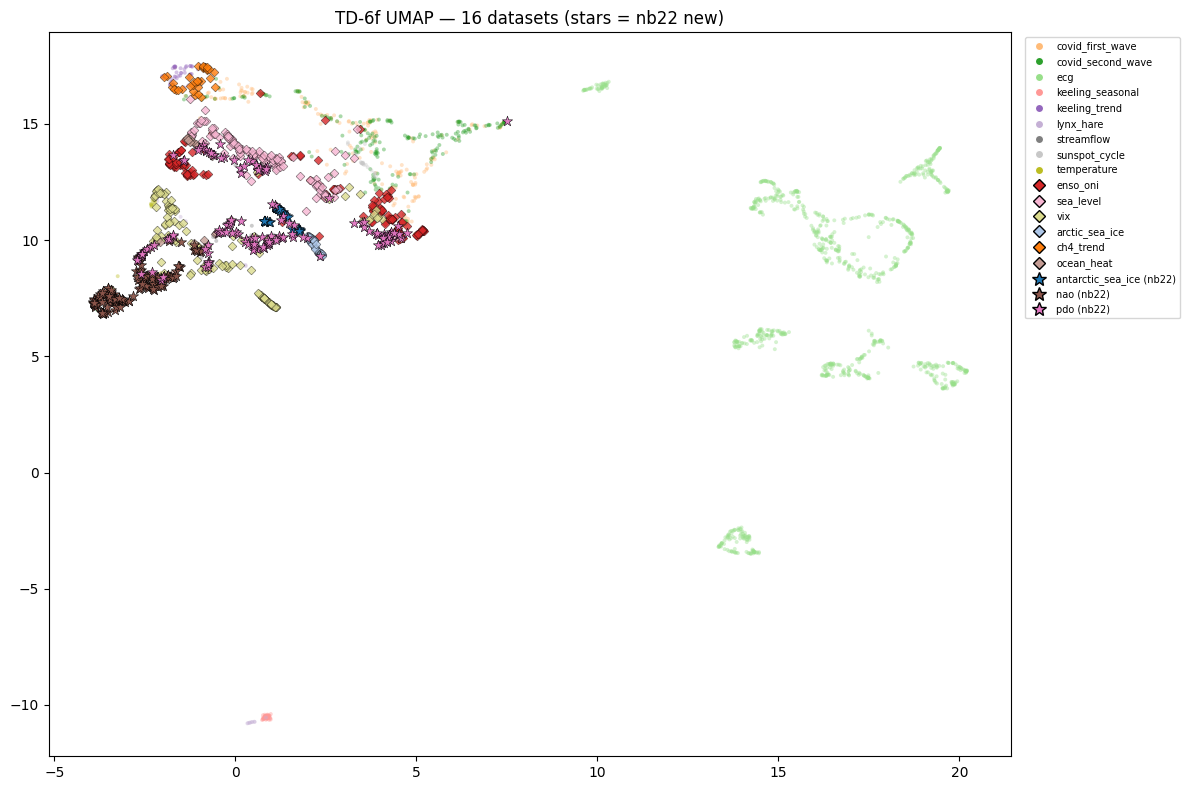

In [21]:
# ============================================================
# TD-6f — where do the 3 new datasets land?
# ============================================================
from sklearn.preprocessing import StandardScaler
import umap

X_feat_raw = df_all[ALL_COLS[:6]].values.astype(float)   # TIMEDOM_COLS
X_feat_sc  = StandardScaler().fit_transform(X_feat_raw)

ALL_EXISTING = ORIG_9 + PHASE1B + PHASE2B

def nearest_existing(ds_new, X=X_feat_sc):
    mask_new = ds_labels == ds_new
    if not mask_new.any(): return None, {}
    c_new = X[mask_new].mean(axis=0)
    dists = {}
    for ds in ALL_EXISTING:
        mask = ds_labels == ds
        if mask.any(): dists[ds] = float(np.linalg.norm(c_new - X[mask].mean(axis=0)))
    return min(dists, key=dists.get), dists

print(f'{"New dataset":22s}  {"Nearest":25s}  {"Dist":6s}  {"2nd nearest":25s}  {"Dist":6s}')
print('-'*90)
for ds_new in PHASE22:
    if ds_new not in DATASETS: continue
    nearest, dists = nearest_existing(ds_new)
    sd = sorted(dists.items(), key=lambda x: x[1])
    n1, d1 = sd[0]; n2, d2 = (sd[1] if len(sd) > 1 else ('—', 0))
    print(f'{ds_new:22s}  {n1:25s}  {d1:6.3f}  {n2:25s}  {d2:6.3f}')

print()
print('Skewness profile (key feature for cl7 test):')
print(f'{"dataset":22s}  {"skewness":>10s}  {"lag1_autocorr":>14s}  {"zero_crossings":>15s}')
ref_ds = ['vix','enso_oni','temperature','wti_oil','copper','arctic_sea_ice','antarctic_sea_ice']
for ds in ref_ds:
    if ds not in DATASETS: continue
    mask = ds_labels == ds
    v = X_feat_raw[mask].mean(axis=0)
    print(f'{ds:22s}  {v[0]:10.3f}  {v[2]:14.3f}  {v[3]:15.3f}')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_feat = reducer.fit_transform(X_feat_sc)

fig, ax = plt.subplots(figsize=(12, 8))
for ds in ORIG_9:
    if ds not in DATASETS: continue
    m = ds_labels == ds
    ax.scatter(emb_feat[m,0], emb_feat[m,1], c=[ds_color[ds]], s=8, alpha=0.4, edgecolors='none')
for ds in PHASE1B + PHASE2B:
    if ds not in DATASETS: continue
    m = ds_labels == ds
    ax.scatter(emb_feat[m,0], emb_feat[m,1], c=[ds_color[ds]], s=20, alpha=0.8,
               marker='D', edgecolors='k', linewidths=0.3)
for ds in PHASE22:
    if ds not in DATASETS: continue
    m = ds_labels == ds
    ax.scatter(emb_feat[m,0], emb_feat[m,1], c=[ds_color[ds]], s=60, alpha=0.95,
               marker='*', edgecolors='k', linewidths=0.4)
handles = ([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds], markersize=6, label=ds)
            for ds in ORIG_9 if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=ds_color[ds], markersize=6,
                        markeredgecolor='k', label=f'{ds}') for ds in PHASE1B+PHASE2B if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=ds_color[ds], markersize=10,
                        markeredgecolor='k', label=f'{ds} (nb22)') for ds in PHASE22 if ds in DATASETS])
ax.legend(handles=handles, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
ax.set_title('TD-6f UMAP — 16 datasets (stars = nb22 new)')
plt.tight_layout(); plt.show()

In [22]:
# ============================================================
# LOAD CHRONOS + EMBED ALL 16 DATASETS
# ============================================================
import torch
from chronos import ChronosPipeline

print('Loading Chronos-T5-Small...')
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small', device_map='cpu', dtype=torch.float32)
encoder = pipeline.model.model.encoder
encoder.eval()
print(f'Encoder loaded. Hidden dim: {encoder.config.d_model}')

def get_chronos_embedding(series_array):
    embeddings = []
    for i, s in enumerate(series_array):
        ts = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        token_ids, attention_mask, _ = pipeline.tokenizer.context_input_transform(ts)
        with torch.no_grad():
            enc_out = encoder(input_ids=token_ids, attention_mask=attention_mask)
        h = enc_out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        emb = (h * mask).sum(dim=1) / mask.sum(dim=1)
        embeddings.append(emb.squeeze(0).numpy())
        if (i+1) % 200 == 0: print(f'  {i+1}/{len(series_array)}...')
    return np.array(embeddings, dtype=np.float32)

print(f'Embedding {len(X_raw_all)} series...')
Z_chronos = get_chronos_embedding(X_raw_all)
print(f'Done. Shape: {Z_chronos.shape}')

Loading Chronos-T5-Small...
Encoder loaded. Hidden dim: 512
Embedding 2356 series...
  200/2356...
  400/2356...
  600/2356...
  800/2356...
  1000/2356...
  1200/2356...
  1400/2356...
  1600/2356...
  1800/2356...
  2000/2356...
  2200/2356...
Done. Shape: (2356, 512)


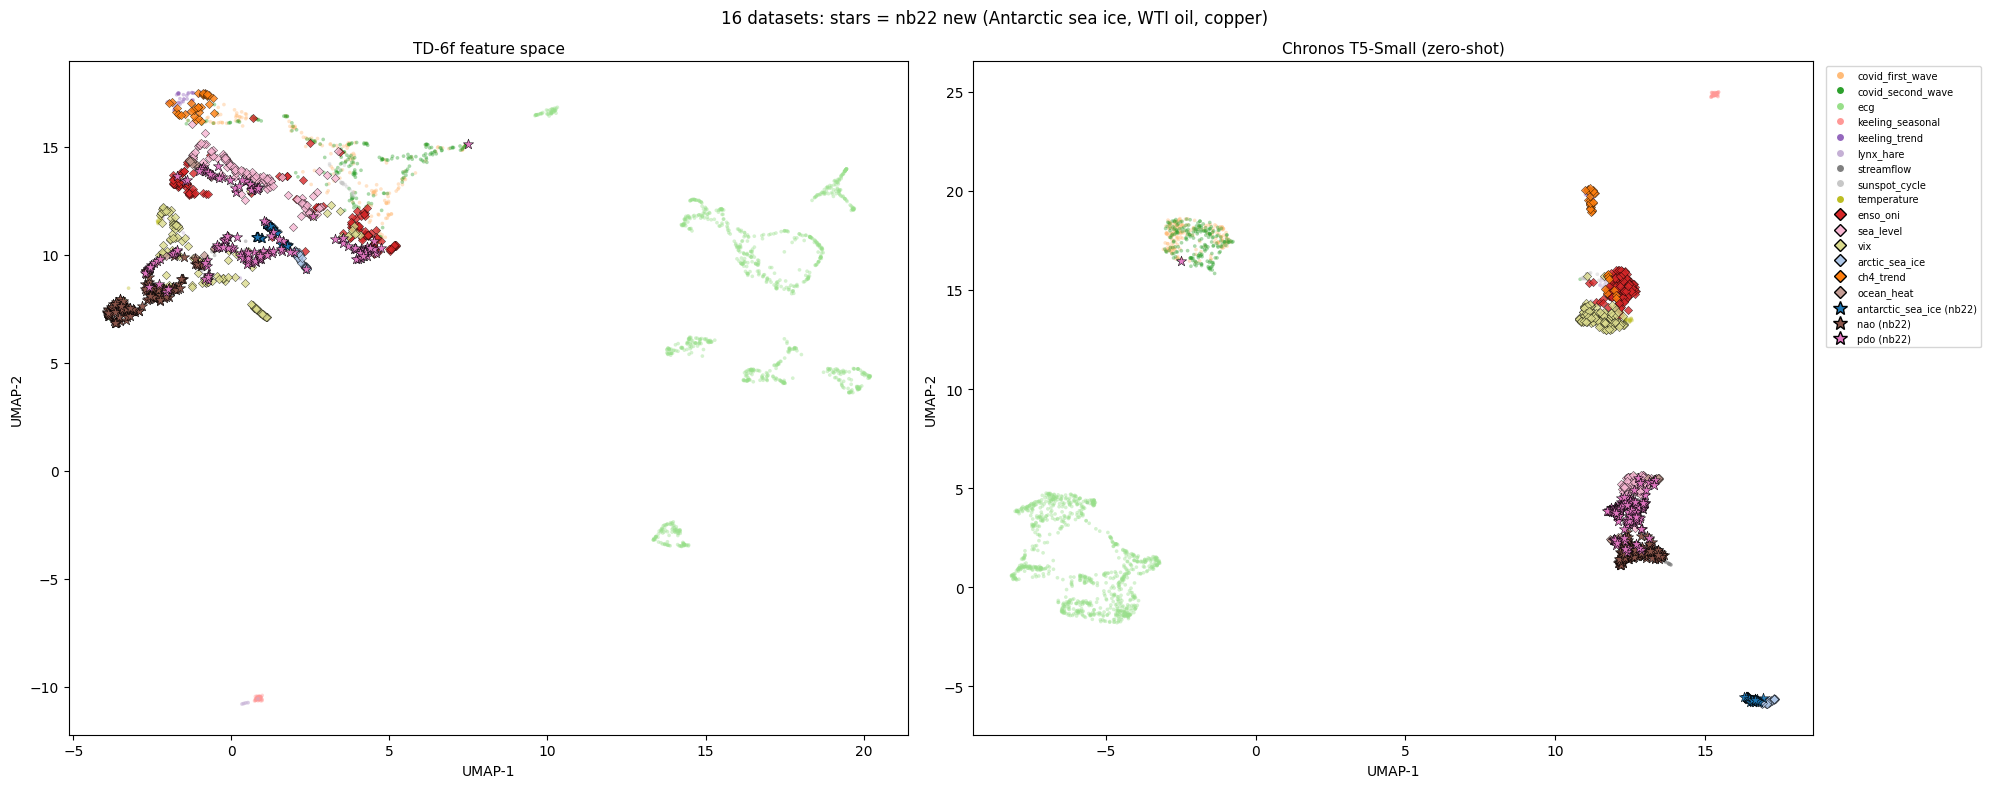


HDBSCAN: 10 clusters, 907 noise (38.5%)

Dataset                    cl-1  cl 0  cl 1  cl 2  cl 3  cl 4  cl 5  cl 6  cl 7  cl 8  cl 9
antarctic_sea_ice          0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=38)
arctic_sea_ice             0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=38)
ch4_trend                  0.39  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.58  0.03  0.00  (n=33)
covid_first_wave           0.80  0.00  0.20  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=202)
covid_second_wave          0.83  0.00  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=209)
ecg                        0.01  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=884)
enso_oni                   0.75  0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.00  0.24  0.00  (n=147)
keeling_seasonal           0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  (n=68)
keeling_trend              0.00  0.00  0.00  0.00  0.00  0.00 

In [23]:
# ============================================================
# CHRONOS UMAP + HDBSCAN — do new datasets replicate nb21 clusters?
# ============================================================
import hdbscan

reducer_ch = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_ch = reducer_ch.fit_transform(Z_chronos)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, emb, title in [
    (axes[0], emb_feat, 'TD-6f feature space'),
    (axes[1], emb_ch,   'Chronos T5-Small (zero-shot)'),
]:
    for ds in ORIG_9:
        if ds not in DATASETS: continue
        m = ds_labels == ds
        ax.scatter(emb[m,0], emb[m,1], c=[ds_color[ds]], s=7, alpha=0.4, edgecolors='none')
    for ds in PHASE1B + PHASE2B:
        if ds not in DATASETS: continue
        m = ds_labels == ds
        ax.scatter(emb[m,0], emb[m,1], c=[ds_color[ds]], s=18, alpha=0.8,
                   marker='D', edgecolors='k', linewidths=0.3)
    for ds in PHASE22:
        if ds not in DATASETS: continue
        m = ds_labels == ds
        ax.scatter(emb[m,0], emb[m,1], c=[ds_color[ds]], s=60, alpha=0.95,
                   marker='*', edgecolors='k', linewidths=0.4)
    ax.set_title(title, fontsize=11); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
handles = ([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds], markersize=6, label=ds)
            for ds in ORIG_9 if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=ds_color[ds], markersize=6,
                        markeredgecolor='k', label=ds) for ds in PHASE1B+PHASE2B if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=ds_color[ds], markersize=10,
                        markeredgecolor='k', label=f'{ds} (nb22)') for ds in PHASE22 if ds in DATASETS])
axes[1].legend(handles=handles, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
plt.suptitle('16 datasets: stars = nb22 new (Antarctic sea ice, WTI oil, copper)')
plt.tight_layout(); plt.show()

print()
cl_ch = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(Z_chronos)
n_cl  = len(set(cl_ch)) - (1 if -1 in cl_ch else 0)
noise = (cl_ch == -1).sum()
print(f'HDBSCAN: {n_cl} clusters, {noise} noise ({100*noise/len(cl_ch):.1f}%)')
print()
print(f'{"Dataset":25s}', end='')
for c in sorted(set(cl_ch)): print(f'  cl{c:2d}', end='')
print()
for ds in DATASETS:
    m = ds_labels == ds; total = m.sum()
    print(f'{ds:25s}', end='')
    for c in sorted(set(cl_ch)):
        frac = (cl_ch[m] == c).sum() / total if total > 0 else 0
        print(f'  {frac:4.2f}', end='')
    print(f'  (n={total})')

In [24]:
# ============================================================
# KEY QUESTION 1: Does Antarctic sea ice join Arctic in cl0?
# KEY QUESTION 2: Do oil/pdo land in cl7?
# ============================================================

# Find which cluster Arctic sea ice is in (should be cl0 from nb21)
for test_ds in ['arctic_sea_ice']:
    m = ds_labels == test_ds
    if m.any():
        dist = {c: (cl_ch[m]==c).sum()/m.sum() for c in sorted(set(cl_ch))}
        dominant = max(dist, key=dist.get)
        print(f'{test_ds}: dominant cluster = cl{dominant} ({dist[dominant]:.1%})')
        arctic_cluster = dominant
    else:
        arctic_cluster = -1

print()
print('Antarctic sea ice cluster distribution:')
m_ant = ds_labels == 'antarctic_sea_ice'
if m_ant.any():
    for c in sorted(set(cl_ch)):
        frac = (cl_ch[m_ant]==c).sum() / m_ant.sum()
        if frac > 0.01:
            match = ' ← SAME as Arctic' if c == arctic_cluster else ''
            print(f'  cl{c}: {frac:.1%}{match}')
else:
    print('  (not loaded)')

print()
print('cl7 composition check — do oil/pdo join VIX/ENSO/temperature?')
# Find the irregular/asymmetric cluster (cl7 from nb21)
target_ds = ['vix','enso_oni','temperature']
cl_scores = {}
for c in sorted(set(cl_ch)):
    if c == -1: continue
    m_c = cl_ch == c
    n_target = sum((ds_labels[m_c] == ds).sum() for ds in target_ds)
    cl_scores[c] = n_target / m_c.sum() if m_c.sum() > 0 else 0
irregular_cl = max(cl_scores, key=cl_scores.get) if cl_scores else -1
print(f'Irregular cluster (VIX+ENSO+temp dominant): cl{irregular_cl}')
print()
for ds in ['vix','enso_oni','temperature','nao','pdo']:
    m = ds_labels == ds
    if not m.any(): continue
    in_cl = (cl_ch[m] == irregular_cl).sum()
    print(f'  {ds:22s}: {in_cl}/{m.sum()} in cl{irregular_cl} ({100*in_cl/m.sum():.0f}%)')

print()
print('Pairwise Chronos distances — new datasets vs key existing:')
def cdist(ds1, ds2):
    m1 = ds_labels == ds1; m2 = ds_labels == ds2
    if not m1.any() or not m2.any(): return float('nan')
    return float(np.linalg.norm(Z_chronos[m1].mean(0) - Z_chronos[m2].mean(0)))

pairs = [
    ('antarctic_sea_ice', 'arctic_sea_ice'),
    ('antarctic_sea_ice', 'keeling_seasonal'),
    ('antarctic_sea_ice', 'sea_level'),
    ('nao',           'vix'),
    ('nao',           'enso_oni'),
    ('nao',           'temperature'),
    ('pdo',            'vix'),
    ('pdo',            'nao'),
    ('nao',           'keeling_trend'),
]
print(f'{"Pair":45s}  {"Chronos":>9s}')
print('-'*60)
for ds1, ds2 in pairs:
    if ds1 not in DATASETS or ds2 not in DATASETS:
        print(f'{ds1+" ↔ "+ds2:45s}  (not loaded)'); continue
    print(f'{ds1+" ↔ "+ds2:45s}  {cdist(ds1,ds2):9.3f}')

arctic_sea_ice: dominant cluster = cl0 (100.0%)

Antarctic sea ice cluster distribution:
  cl0: 100.0% ← SAME as Arctic

cl7 composition check — do oil/pdo join VIX/ENSO/temperature?
Irregular cluster (VIX+ENSO+temp dominant): cl8

  vix                   : 40/138 in cl8 (29%)
  enso_oni              : 36/147 in cl8 (24%)
  temperature           : 7/31 in cl8 (23%)
  nao                   : 0/143 in cl8 (0%)
  pdo                   : 0/146 in cl8 (0%)

Pairwise Chronos distances — new datasets vs key existing:
Pair                                             Chronos
------------------------------------------------------------
antarctic_sea_ice ↔ arctic_sea_ice                 0.072
antarctic_sea_ice ↔ keeling_seasonal               0.276
antarctic_sea_ice ↔ sea_level                      0.269
nao ↔ vix                                          0.192
nao ↔ enso_oni                                     0.240
nao ↔ temperature                                  0.191
pdo ↔ vix               

## Findings — Notebook 22

### Finding 53: [Antarctic sea ice + Arctic sea ice — same cluster?]

**Prediction:** Antarctic sea ice joins cl0 (declining oscillator) with Arctic sea ice.

**Result:** *(run to find out)*

---

### Finding 54: [NAO — lands in cl7 alongside ENSO?]

**Prediction:** Irregular Atlantic climate oscillation joins cl7. Tests whether cl7 is a general "irregular oscillation" class or specific to Pacific/financial data.

**Result:** *(run to find out)*

---

### Finding 55: [PDO — lands with ENSO or in its own region?]

**Prediction:** Pacific Decadal Oscillation (same basin as ENSO, longer timescale) lands in cl7 or near ENSO. If both NAO and PDO land in cl7, the class captures all major irregular climate oscillations.

**Result:** *(run to find out)*